## MDS for the digit dataset

The dimension of X is: (1797, 64)


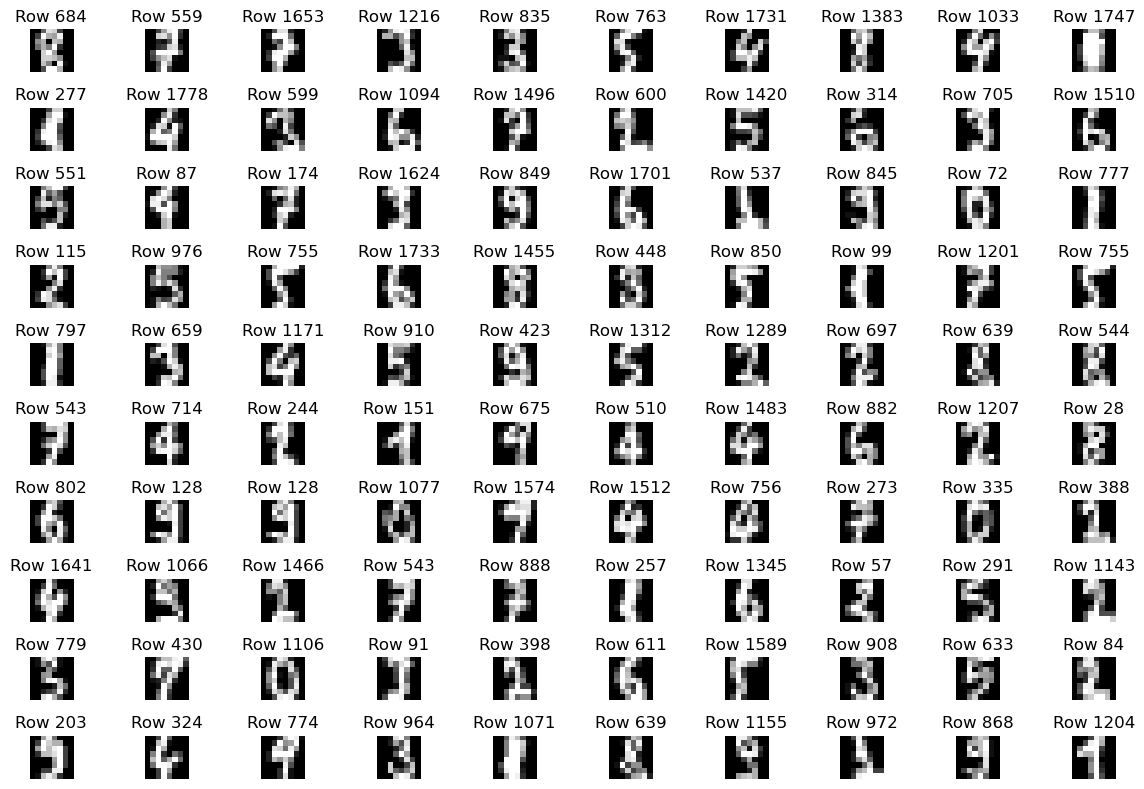

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.manifold import MDS
import matplotlib.pyplot as plt


digits_tuple = load_digits(return_X_y=True)
X = digits_tuple[0]
y = digits_tuple[1]
# contains the label for each image stored in 'X'.
# However, do note that MDS is an unsupervised learning, i.e., the algorithm does not know the image labels at all!

print(f"The dimension of X is: {X.shape}")
# 1797 samples (images), 64 features (8x8 pixel for each image)

# Display the data stored in 'X'. For demonstration purpose, we'll only be displaying randomly chosen 100 samples (rows of 'X')
np.random.seed(0)
img2Display = np.random.randint(0, X.shape[0], size=100)
fig, axes = plt.subplots(10, 10, figsize=(12, 8))
for i, ax in enumerate(axes.flat):

    image = X[img2Display[i]].reshape(8, 8) # Reshape each specified row in img2Display into an 8x8 image
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Row {img2Display[i]}")
    ax.axis('off')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


The dimension of X_transformed is: (500, 2)


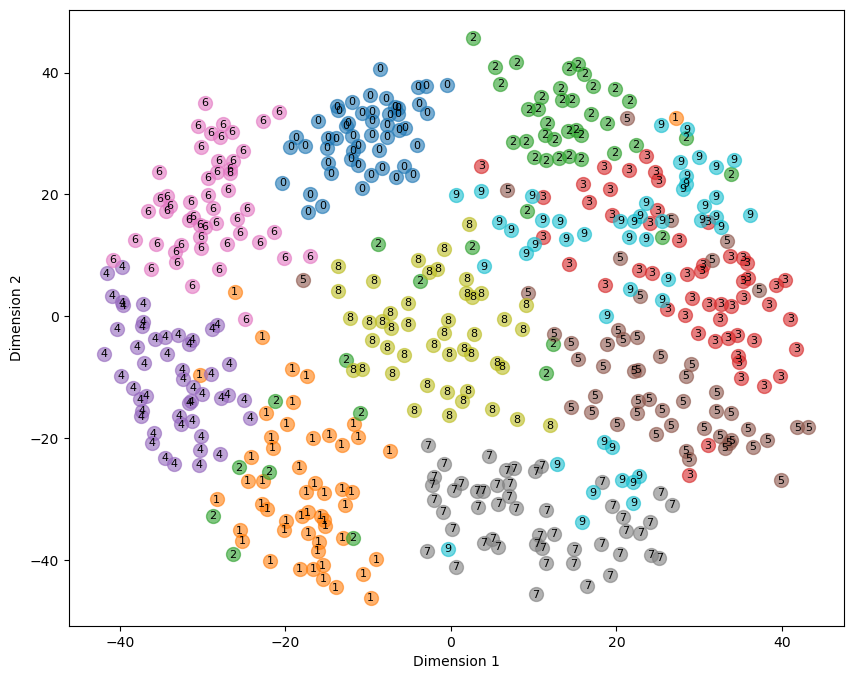

In [2]:
embedding = MDS(n_components=2, metric=True, normalized_stress='auto', random_state=0, dissimilarity='euclidean') # perform metric MDS

# for the sake of demonstrate and speed consideration, we'll just transform and plot 500 of the original 1797 samples here
numOfDataPts2Plot = 500
X_transformed = embedding.fit_transform(X[:numOfDataPts2Plot])
y_X_transformed = y[:numOfDataPts2Plot]

print(f"The dimension of X_transformed is: {X_transformed.shape}")

plt.figure(figsize=(10, 8))

unique_classes = np.unique(y_X_transformed)

for class_label in unique_classes:
  class_points = X_transformed[y_X_transformed == class_label]
  plt.scatter(class_points[:, 0], class_points[:, 1], label=str(class_label), s=100, alpha=0.6)

  for i in range(len(class_points)):
        plt.text(class_points[i, 0], class_points[i, 1], str(class_label),
                 fontsize=8, ha='center', va='center')

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()